In [15]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
 

In [ ]:
# URL del archivo en el bucket público de AWS
url = "https://hybridge-education-machine-learning-datasets.s3.us-east-1.amazonaws.com/Fraud.csv"
df = pd.read_csv(url)

In [2]:
df = pd.read_csv("Fraud.csv")

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
len(df)

6362620

# ¡¡¡6,362,620 OBSERVACIONES!!!

In [5]:
df.info()
df.notnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


step              6362620
type              6362620
amount            6362620
nameOrig          6362620
oldbalanceOrg     6362620
newbalanceOrig    6362620
nameDest          6362620
oldbalanceDest    6362620
newbalanceDest    6362620
isFraud           6362620
isFlaggedFraud    6362620
dtype: int64

**Descripción de las variables:**

- **step:** instante o paso temporal de la transacción.

- **type:** tipo de transacción, por ejemplo PAYMENT, TRANSFER o CASH_OUT.

- **amount:** monto de la operación.

- **nameOrig:** identificador de la cuenta o cliente de origen.

- **oldbalanceOrg:** saldo anterior de la cuenta de origen.

- **newbalanceOrig:** saldo posterior de la cuenta de origen.

- **nameDest:** identificador de la cuenta o cliente de destino.

- **oldbalanceDest:** saldo anterior de la cuenta de destino.

- **newbalanceDest:** saldo posterior de la cuenta de destino.

- **isFlaggedFraud:** indicador automático que marca transacciones sospechosas; normalmente es una variable auxiliar, no la objetivo principal.

- **isFraud:** variable objetivo. Vale 1 si la transacción es fraude y 0 si es legítima.

In [6]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

<Axes: >

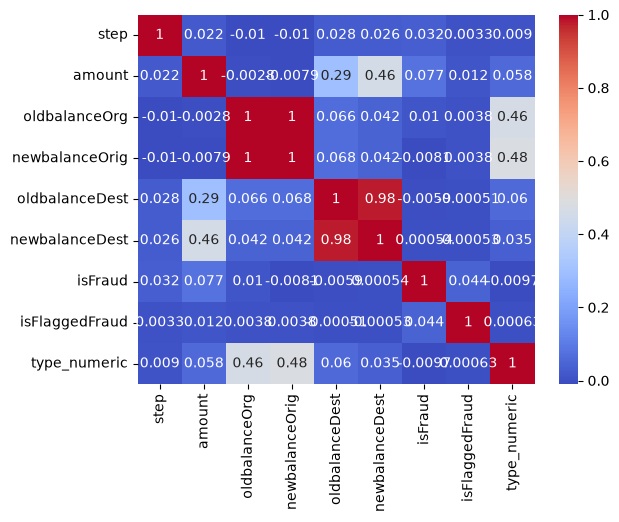

In [7]:
df_correlaciones = df.copy()
df_correlaciones["type_numeric"] = df_correlaciones["type"].map({"CASH_OUT": 1, "PAYMENT": 2, "TRANSFER": 3, "DEBIT": 4, "CASH_IN": 5})

df_correlaciones_numericas = df_correlaciones.select_dtypes(include=[np.number])
sns.heatmap(df_correlaciones_numericas.corr(), annot=True, cmap='coolwarm')


In [17]:
df.head()
#df["nameDest"].value_counts()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [20]:
df_transformado = df.copy()
encoder = LabelEncoder()
df_transformado["type"] = encoder.fit_transform(df_transformado["type"])
df_transformado.drop(columns=["nameDest", "nameOrig"], inplace=True)
df_transformado.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,4,181.00,181.0,0.00,0.0,0.0,1,0
3,1,1,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0,0


In [28]:
df_transformado.value_counts(subset=["newbalanceDest"])

newbalanceDest
0.00              2439433
10000000.00            53
971418.91              32
19169204.93            29
1254956.07             25
                   ...   
283532.09               1
339850.17               1
1762283.33              1
6379898.11              1
7360101.63              1
Name: count, Length: 3555499, dtype: int64

In [33]:
# Separar características y variable objetivo
X = df_transformado.drop(columns=["isFraud"])  # Características
y = df_transformado["isFraud"]

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar el modelo inicial
model = LogisticRegression(random_state=42, max_iter=100)
model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Evaluación inicial
print("\nReporte de clasificación (Prueba):")
print(classification_report(y_test, y_pred_test))


Reporte de clasificación (Prueba):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.89      0.43      0.58      1643

    accuracy                           1.00   1272524
   macro avg       0.94      0.72      0.79   1272524
weighted avg       1.00      1.00      1.00   1272524



**Conclusiones:**

El criterio principal no es maximizar accuracy, sino minimizar falsos negativos en la clase fraude. Por ello, se prioriza el recall, ya que cada fraude no detectado representa una pérdida potencial mayor que un falso positivo. Tambien hay un desbalance remarcable en la variable objetivo. Por todo lo anterior es mejor cambiar a un modelo que soporte el desbalance como BalancedRandomForestClassifier o XGBoost con desbalance.